## Introduction

In this kernel, we will understand the structure of the dataset, check the ratio of the normal transactions and fraud transactions. Based on the transaction ratio we will identify which variable contribute most to fraud transaction, and create synthetic fraud transaction randomly to check the model performance.

## Our Goals
1. If needed, we will convert the data to 


In [40]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



First of all, we load the dataset uising pandas and display first five rows to understand the structure, and feature names.


In [39]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


We examine the dataset dimensions, data types, and basic statistical properties to understand the size of the data, check for missing values, and gain insights into the distribution of numerical features. 
The total number of columns is 284807, and we can see that each variable and data has no missing data.

In [11]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

By converting the transaction counts into percentages, we can clearly observe the rarity of fraud events (Class 1). This highlights the extreme class imbalance present in the dataset.

Matplotlib is building the font cache; this may take a moment.


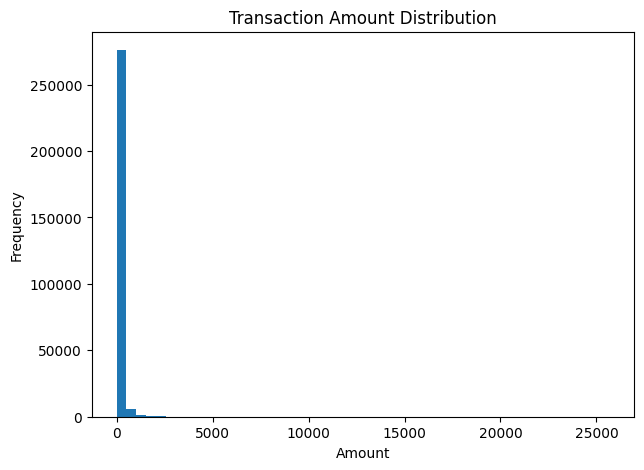

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()



As seen in the plot, the data shows a heavy skew toward small payments. To ensure our machine learning model isn't biased by this long-tail distribution, we weill use log transformation to achieve a more normal distrubution.


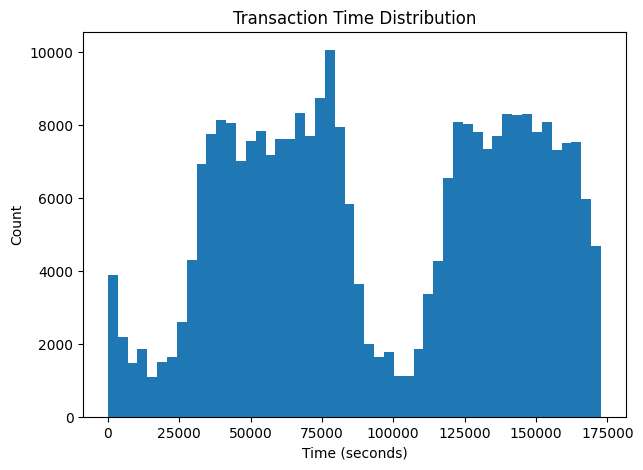

In [13]:
plt.figure(figsize=(7,5))
plt.hist(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Count")
plt.show()

The peaks and troughs illustrate a typical daily cycle. If fraudulent transactions are found to be concentrated during nighttime (the troughs of the graph), the Time feature could serve as a critical indicator for fraud detection.

In [51]:
compare_amount = pd.concat([
    df[df["Class"] == 0]["Amount"].describe(),
    df[df["Class"] == 1]["Amount"].describe()
], axis=1)

compare_amount.columns = ['Normal (Class 0)', 'Fraud (Class 1)']
compare_amount

,Normal (Class 0),Fraud (Class 1)
count,284315.000000,492.000000
mean,88.291022,122.211321
std,250.105092,256.683288
min,0.000000,0.000000
25%,5.650000,1.000000
50%,22.000000,9.250000
75%,77.050000,105.890000
max,25691.160000,2125.870000


### **Analysis of Fraudulent Transaction Amounts**

The descriptive statistics reveal a significant disparity in fraudulent transactions:

* **Mean vs. Median Gap:** The **median is \$9.25**, while the **average is \$122.21**. This indicates that a small number of high-value fraudulent transactions are significantly skewing the average upward.
* **Concentration of Low-Value Fraud:** **75% of fraudulent transactions are below \$105.89**. This shows that 3 out of 4 scammers prefer transactions under this threshold to avoid detection.
* **Dual Strategy Identification:** Even though the majority are small, the **maximum value of \$2,125.87** proves that fraudsters employ a **dual strategy**:
    1.  **Small Repeated Payments:** To fly under the radar.
    2.  **One Large Withdrawal:** To maximize theft in a single hit.

**Conclusion:** Our model must be robust enough to capture both of these **heterogeneous patterns** to ensure effective detection.

In [52]:
# 1. Check the number of columns
print("="*50)
print("1. Class number of columns")
class_counts = df_credit_card['Class'].value_counts()
print(class_counts)

# 2. Check the ratio of the column
print("="*50)
print("2. Class columns ratio (%)")
class_distribution = df_credit_card['Class'].value_counts(normalize=True) * 100
print(class_distribution)

# Number of fraud
fraud_count = class_counts[1]
total_count = len(df_credit_card)
fraud_percentage = class_distribution[1]

print("\n--- Number of fruad ---")
print(f"Transactions: {total_count}")
print(f"fraud transaction (Class=1): {fraud_count}")
print(f"fraud transaction ratio: {fraud_percentage:.4f}%")
print("="*50)

1. Class number of columns
Class
0    284315
1       492
Name: count, dtype: int64
2. Class columns ratio (%)
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

--- Number of fruad ---
Transactions: 284807
fraud transaction (Class=1): 492
fraud transaction ratio: 0.1727%


Before proceeding with modeling, we analyzed the actual proportion of fraudulent data. The fraud rate is only 0.1727%, which implies that even if we predicted all transactions as normal (0), we would still achieve an accuracy of 99.83%. Therefore, rather than focusing on accuracy, this project will adopt Recall (how effectively we detect actual fraud) and Precision (how accurately we identify fraud) as the primary performance metrics.

In [11]:
print("="*50)
print("[Amount 컬럼 통계 요약]")
# Amount 컬럼의 기술 통계량 확인
print(df_credit_card['Amount'].describe())

[Amount 컬럼 통계 요약]
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [14]:
# Import the necessary module for standardization
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# 1. Standardize the 'Amount' column and store it in a new column 'Scaled_Amount'.
# .reshape(-1, 1) converts the 1D array into the 2D format required by the scaler.
df_credit_card['Scaled_Amount'] = scaler.fit_transform(df_credit_card['Amount'].values.reshape(-1, 1))

# 2. Verify the standardization result for 'Scaled_Amount'
print("="*50)
print("[Amount Standardization Result]")
print(df_credit_card['Scaled_Amount'].describe())

[Amount Standardization Result (Scaled_Amount)]
count    2.848070e+05
mean    -3.672378e-17
std      1.000002e+00
min     -3.532294e-01
25%     -3.308401e-01
50%     -2.652715e-01
75%     -4.471707e-02
max      1.023622e+02
Name: Scaled_Amount, dtype: float64


### **Feature Engineering: Scaling the Amount**

To ensure the model treats all features fairly, we standardize the **Amount** feature:

1.  **Why Scale?**: The raw `Amount` varies from \$0 to over \$25,000. Large values can dominate the model's learning process.
2.  **Method**: We used `StandardScaler` to transform the data to have a mean of 0 and a standard deviation of 1.
3.  **Result**: 
    * **Original Max**: \$25,691.16 
    * **Scaled Max**: 102.36 (Z-score)

**Note:** While scaling helps, the extreme max value suggests that **outliers** are still present. This confirms our previous plan to apply log transformation to handle the skewed distribution.

In [15]:
from sklearn.model_selection import train_test_split

# 1. Define X (Features) and y (Target)
# Exclude 'Time', 'Amount', and the target 'Class'
X = df_credit_card.drop(['Time', 'Amount', 'Class'], axis=1) 
y = df_credit_card['Class']

# 2. Split into Training (70%) and Test (30%) sets
# 'stratify=y' ensures the 0.17% fraud ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

# 3. Check the fraud ratio in the training set
print("="*50)
print("Fraud ratio in Training Set (%):")
print(y_train.value_counts(normalize=True) * 100)
print("="*50)

Fraud ratio in Training Set (%):
Class
0    99.827451
1     0.172549
Name: proportion, dtype: float64


### **Preparing Training and Test Datasets**

We split the data to prepare for the modeling phase, focusing on maintaining the integrity of the minority class.

1.  **Feature Selection**: Dropped raw `Time` and `Amount` columns. `Time` was excluded to reduce noise, and `Amount` was replaced by its scaled version.
2.  **Stratified Splitting**: By setting `stratify=y`, we ensured the **0.17% fraud ratio** is consistently represented in both the 70% training set and the 30% test set.
3.  **Reproducibility**: `random_state=42` was used to ensure the results remain consistent across different runs.

**Result**: The training set now has a balanced representation of the fraud class, which is crucial for the model to learn the characteristics of fraudulent transactions.

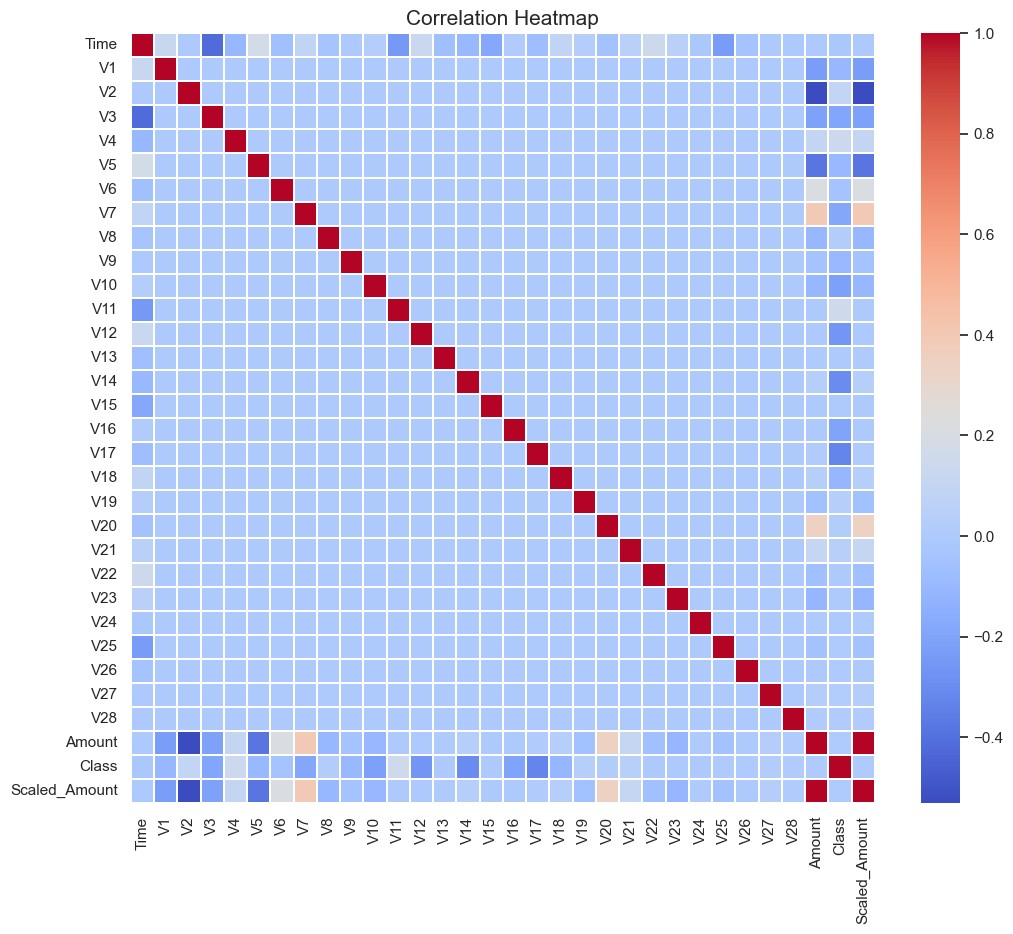

In [18]:
### **5. Exploratory Data Analysis: Correlation Heatmap**

To identify the most influential features for fraud detection, we visualize the correlation matrix:

1.  **Objective**: Find features that have a strong relationship with the target `Class`.
2.  **Observation**: 
    * Most $V$ features show low correlation with each other, confirming the properties of PCA.
    * Specific features (e.g., $V17$, $V14$) often show distinct colors in the `Class` row, indicating high predictive power.
3.  **Strategy**: These highly correlated features will be the focus of our model's decision-making process.

### **Exploratory Data Analysis: Correlation Heatmap**

To identify the most influential features for fraud detection, we visualize the correlation matrix:

1.  **Objective**: Identify features that exhibit a strong relationship with the target variable, 'Class'.
2.  **Observation**: 
    * Most V features show low correlation with one another, which confirms the inherent properties of PCA (Principal Component Analysis)       used in this dataset.
    * Specific features (e.g., $V12$, $V14$, $V4$, $V11$ **6. Detailed Analysis of Key Features using Box Plots**
We utilize box plots to examine the distribution of features that exhibited high correlation with the target variable.

* **Median Separation:** A significant vertical gap between the medians of **Class 0** and **Class 1** indicates high **discriminatory power**.
* **Negative Correlations ($V14, V12$):** Fraudulent transactions show a noticeable downward shift. **$V14$** displays the most distinct separation, making it a primary feature for detection.
* **Positive Correlations ($V4, V11$):** Fraud cases tend to result in significantly higher values compared to normal transactions, which are tightly clustered around zero.
* **Outliers:** The presence of numerous outliers in the fraud class highlights the extreme and varied nature of fraudulent activities.

**Strategy:** The clear distributional differences confirm that these features are essential for the model to establish an effective **decision boundary**.$) often show distinct colors in the `Class` row, indicating high predictive power.
3.  **Strategy**: These highly correlated features will be the focus of our model's decision-making process.

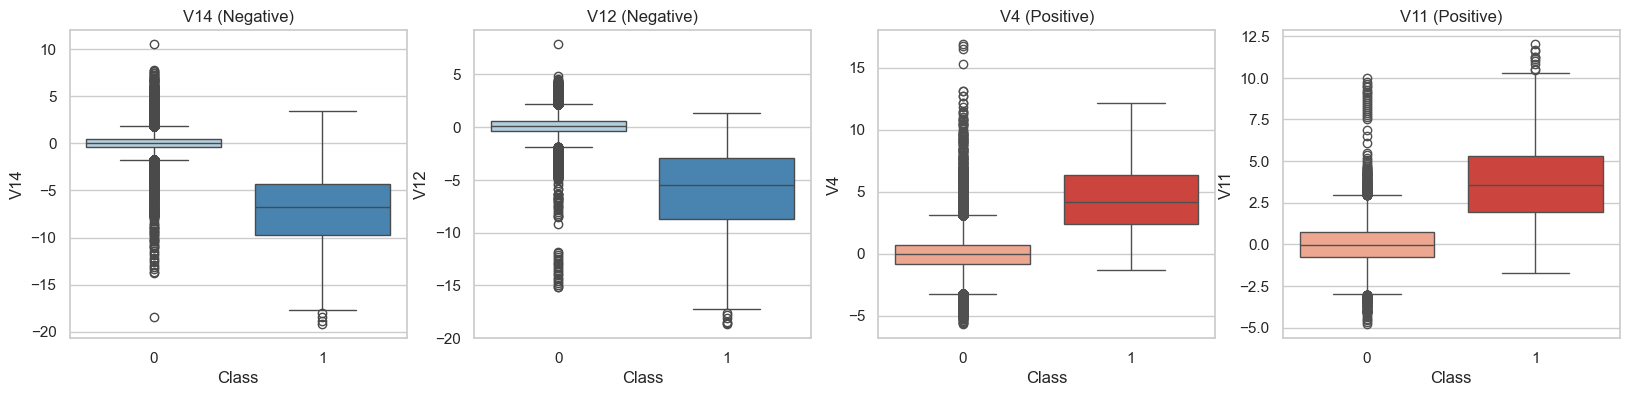

In [21]:
# Select the top features based on correlation to visualize together
f, axes = plt.subplots(ncols=4, figsize=(20,4))

# 1. Negative Correlation: V14
sns.boxplot(x="Class", y="V14", data=df_credit_card, palette='Blues', hue='Class', legend=False, ax=axes[0])
axes[0].set_title('V14 (Negative)')

# 2. Negative Correlation: V12
sns.boxplot(x="Class", y="V12", data=df_credit_card, palette='Blues', hue='Class', legend=False, ax=axes[1])
axes[1].set_title('V12 (Negative)')

# 3. Positive Correlation: V4
sns.boxplot(x="Class", y="V4", data=df_credit_card, palette='Reds', hue='Class', legend=False, ax=axes[2])
axes[2].set_title('V4 (Positive)')

# 4. Positive Correlation: V11
sns.boxplot(x="Class", y="V11", data=df_credit_card, palette='Reds', hue='Class', legend=False, ax=axes[3])
axes[3].set_title('V11 (Positive)')

plt.show()

#### Detailed Analysis of Key Features using Box Plots

First, based on the correlation heatmap, the four variables with the strongest correlations were selected and visualized using box plots.

For V14 and V12, normal transactions (Class 0) are tightly clustered around zero, whereas fraudulent transactions (Class 1) show a clear shift of the median toward the negative region.

This indicates a distinct difference in the distributions between the two classes.
Similarly, for V4 and V11, normal transactions (Class 0) are concentrated around zero, while fraudulent transactions (Class 1) are shifted toward the positive region.

In addition, the box plots for fraudulent transactions generally exhibit larger interquartile ranges compared to those of normal transactions. This suggests that fraudulent transactions span a wider range of values and exhibit higher variability than normal transactions.


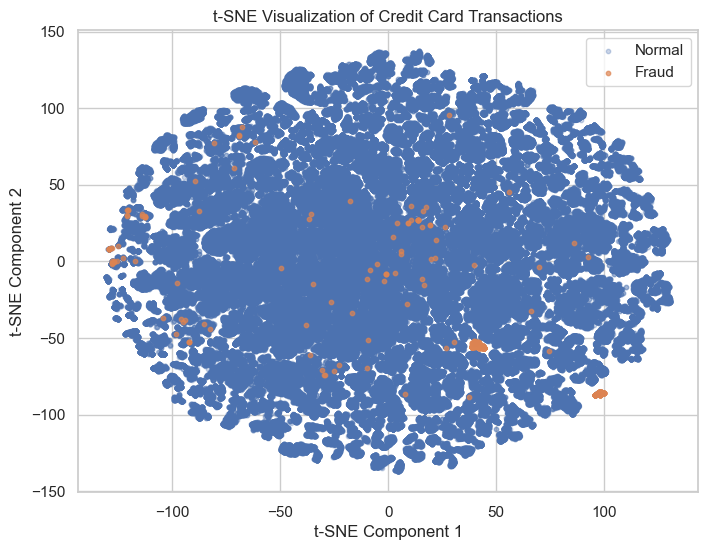

In [57]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1],
            alpha=0.3, label='Normal', s=10)
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1],
            alpha=0.7, label='Fraud', s=10)

plt.legend()
plt.title("t-SNE Visualization of Credit Card Transactions")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

Using t-SNE, the overall structure of the transaction data was visualized.
The fraudulent transactions do not form a single, well-defined cluster; instead, they are scattered throughout the space occupied by normal transactions.

This observation suggests that fraudulent transactions partially share similar patterns with normal transactions and exist in various forms that partially mimic legitimate behavior.

Consequently, this problem requires models capable of learning non-linear patterns in order to effectively distinguish fraudulent transactions from normal ones.

In [15]:
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE

sm = SMOTE(random_state=42)


X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


print('---- SMOTE Applied ----')
print(f'Before SMOTE (Training Set): {y_train.value_counts().to_dict()}')
print(f'After SMOTE (Training Set): {y_train_res.value_counts().to_dict()}')

---- SMOTE Applied ----
Before SMOTE (Training Set): {0: 227451, 1: 394}
After SMOTE (Training Set): {0: 227451, 1: 227451}


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


lr_model = LogisticRegression(max_iter=1000)


lr_model.fit(X_train_res, y_train_res)


y_pred = lr_model.predict(X_test)


print('---- Logistic Regression Model Evaluation ----')
print(classification_report(y_test, y_pred))

---- Logistic Regression Model Evaluation ----
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Settings and Learning

Model Configuration and Training
To evaluate the model performance, a Logistic Regression model was applied.


Algorithm
Logistic Regression was used to predict the probability of fraudulent transactions. Logistic Regression is a classification algorithm that estimates the probability of an event occurring based on a linear combination of input features. It is commonly used in binary classification problems such as normal versus fraudulent transactions and is often employed as a strong baseline model.

Hyperparameter Setting
max_iter = 1000: The model went through 1000 trials and errors to get close to the correct answer. The regression model requires enough trials and errors to reduce errors through repeated calculations

Training Data: used the SMOTE technique to solve the imbalance problem. The SMOTE technique is to balance the data by generating the fake data in order for the model to learn the unbalanced fraud patterns from the unbalanced data.


recall: the percentage of actual fraudulent transactions captured by the model as fraud. It is the most important indicator in fraud detection systems. 
Precision: This is the percentage of actual frauds that the model predicts to be fraudulent. It measures customer inconvenience caused by false detection.
F1-Score: a harmonic average of precision and reproducibility, showing the balance between the two metrics.


The high figure of recall is 0.90, but the value of the precision is so low that we can see that the f-score has dropped a lot, so we can observe that only 6% of the transactions that the model predicts to be fraudulent are actually fraudulent.


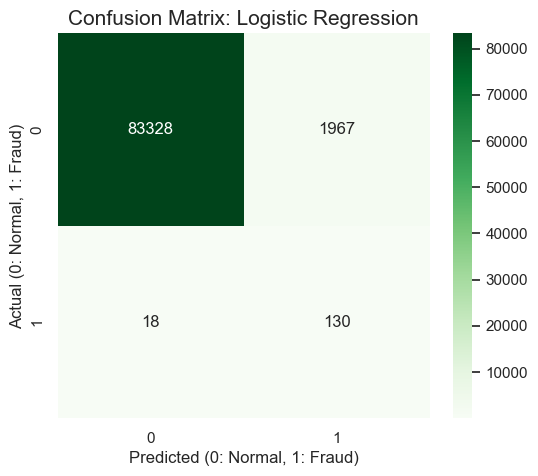

In [30]:
# Create a Confusion Matrix visual
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: Logistic Regression', fontsize=15)
plt.xlabel('Predicted (0: Normal, 1: Fraud)')
plt.ylabel('Actual (0: Normal, 1: Fraud)')
plt.show()

Key Statistics

Key Statistics (Performance Summary)
True Negatives (Normal correctly classified as normal): 83,328
True Positives (Fraud correctly classified as fraud): 130 (successful detections)
False Negatives (Fraud misclassified as normal): 18 (missed fraud cases — high risk)
False Positives (Normal misclassified as fraud): 1,967 (false alarms — customer inconvenience)

Visual Insights

Visual Insights
Evidence of High Recall
Out of 148 actual fraudulent transactions (130 true positives + 18 false negatives), the model successfully identified 130 cases. This demonstrates that the model is highly sensitive to fraudulent patterns and is effective at capturing most fraud cases.

Cause of Low Precision
The 1,967 false positives in the upper-right quadrant are the key factor behind the low precision. Among the 2,097 transactions predicted as fraudulent (1,967 + 130), only 130 were actually fraud, while the remaining approximately 2,000 transactions were legitimate, leading to a high rate of false alarms.

Practical application
This model adopts an aggressive detection strategy, effectively flagging any transaction with even a slight indication of fraud. From a financial security perspective, this approach is effective in minimizing direct losses caused by missed fraud cases (18 instances). However, it comes at the cost of increased customer inconvenience due to frequent false positives.

In [17]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


rf_model.fit(X_train_res, y_train_res)


y_pred_rf = rf_model.predict(X_test)


print('---- Random Forest Model Evaluation ----')
print(classification_report(y_test, y_pred_rf))

---- Random Forest Model Evaluation ----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



Random Forest Model


Algorithm
Following the Logistic Regression model, a Random Forest model was applied as a more complex and powerful algorithm. Random Forest is an ensemble learning method that combines multiple decision trees, enabling it to capture non-linear relationships and feature interactions that linear models may fail to represent.

What to Look For
Reduce False Positive
Determine how much approximately 2,000 false detections (misleading normal to fraud) occurred in logistic regression have been reduced in random forests. Usually, tree-based models tend to capture nonlinear relationships well and thus significantly improve precision.

Keep False Negative
Check that Recall is not significantly lower compared to logistic regression.


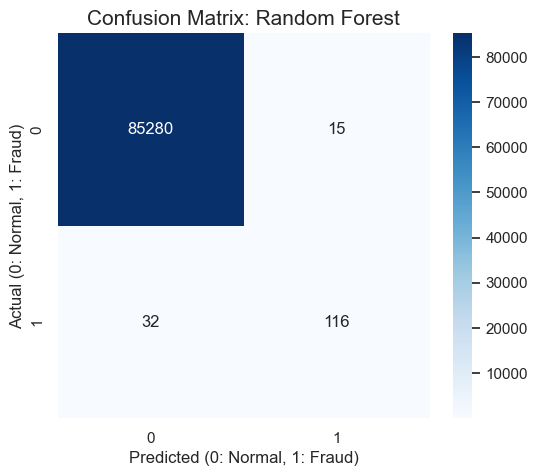

In [32]:
# Create a Confusion Matrix visual for Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Random Forest', fontsize=15)
plt.xlabel('Predicted (0: Normal, 1: Fraud)')
plt.ylabel('Actual (0: Normal, 1: Fraud)')
plt.show()

Key Statistics 

Random Forest Performance
True Negatives (Normal correctly classified as normal): 85,280
True Positives (Fraud correctly classified as fraud): 116
False Negatives (Fraud misclassified as normal): 32 (missed fraud cases — risk)
False Positives (Normal misclassified as fraud): 15 (false alarms — customer inconvenience)


Visual Insights

Reasons for High Recall: We caught 130 out of 148 (18 + 116) real fraudulent transactions. It shows that the model is very sensitive to fraudulent patterns.
Causes of low precision: Note 1,967 cases in the upper right corner. Of the 2,097 cases (1,967 + 130) that the model predicted were frauds, only 130 were actual frauds, and the remaining 2,000 were innocent normal transactions.
Practical application: The model takes an aggressive detection strategy that "filters out and sees any possibility of fraud." In terms of financial security, it is effective in reducing direct losses (18 cases) caused by missing fraud.

Although logistic regression has excellent recall ability, there were many cases where normal was mistaken for fraud at 1,967. However, Random Forest reduced false detections (FPs) by about 130 times from 1,967 to 15. Although the fraud detection rate is slightly lower than that of logistic, it controls false detections close to perfect and shows very high precision. It is the most well-balanced model in practice.

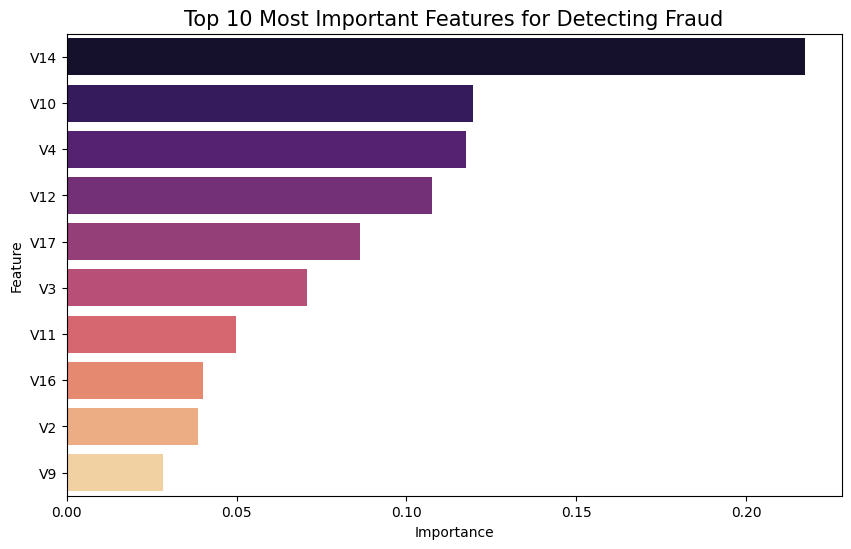

In [18]:
import pandas as pd

# Get feature importance from the RF model
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma', hue='Feature', legend=False)
plt.title('Top 10 Most Important Features for Detecting Fraud', fontsize=15)
plt.show()

Regression models make decisions by combining a number of Decision Trees. This process allows you to quantify how much each feature contributed to separating fraud from normal. 

By analyzing the top 10 features, we can confirm that the model is not just memorizing, but also capturing certain patterns of fraudulent transactions (e.g., abrupt numerical changes in certain V variables).

The graph above shows that the values of V17, V14, and V12 are the key variables in fraud.

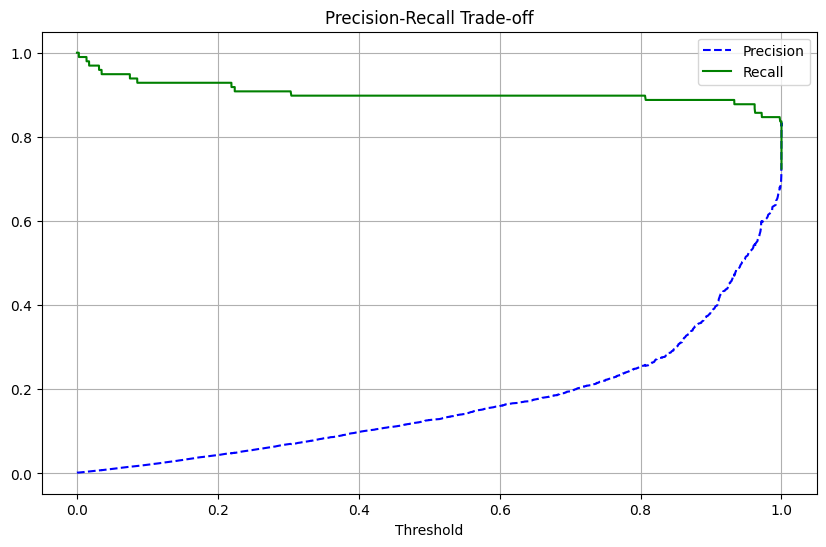

In [23]:
from sklearn.metrics import precision_recall_curve


y_scores = lr_model.predict_proba(X_test)[:, 1]


precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)


plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.grid()
plt.show()

A Precision-Recall Trade-off graph of logistic regression, which shows how the performance of precision and recall changes as thresholds increase.

Each model calculates the probability of fraud in the form of a score for each transaction and classifies it as a fraudulent transaction if the probability exceeds a predefined probability value, where the predefined probability value is the threshold value
In this graph, you can observe that the value of the precision increases as the threshold approaches 1, which means that most of the transactions that the model predicts to be fraudulent are actually fraudulent transactions, 

The results of the logistic regression that we are seeing now are sensitive to decreasing reproducibility with increasing thresholds. The precision rises sensitively and then increases sharply from 0.8. This very often captures fraudulent transactions because of high reproducibility, even when thresholds are low, but low precision can damage innocent customers. 

Given that the intersection of the two indicators is located between 0.95 and 1.0, we find that the logistic regression model shows meaningful screening only at extremely high thresholds. However, in this section, the reproduction rate drops dramatically, missing a significant portion of the actual fraudulent transactions.

This suggests that this model has limitations in operating with threshold adjustments only in matters where Recall and Precision balance is important, such as fraud detection. Nonlinear models such as Random Forest or additional cost-based decision-making strategies are needed in real-world production environments.


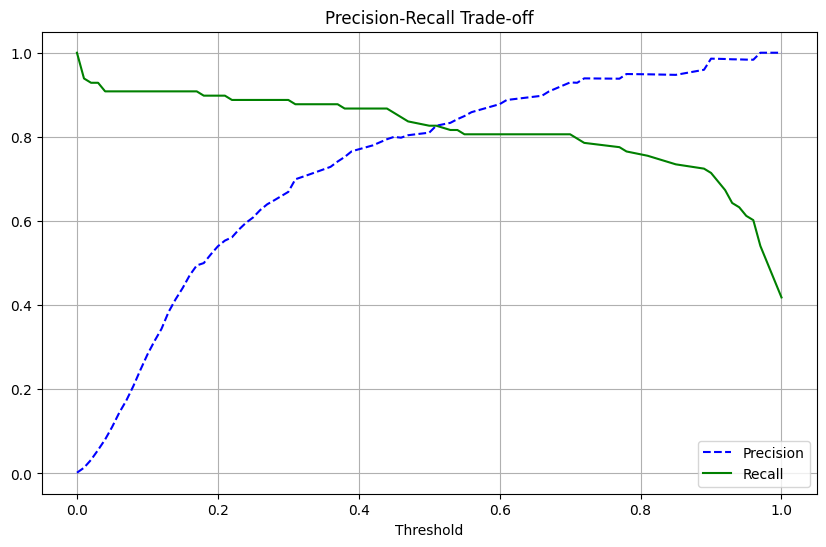

In [19]:
from sklearn.metrics import precision_recall_curve

y_scores = rf_model.predict_proba(X_test)[:, 1]


precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)


plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.grid()
plt.show()

Precision-Recall Trade-off graph of logistic regression.

In this graph, the (0-0.2) reproducibility in the low threshold interval is comparable to that in logistic regression. However, the precision rises sharply in almost every interval, unlike logistic regression.
In the middle threshold interval, the two lines intersect (0.4 to 0.6) This shows that it is a threshold interval with moderate fraud and no false positives.
The precision at high threshold intervals (0.8 to 1.0) shows the best performance, but the reproduction rate drops dramatically. This is only when the model is convinced that this is a real scam, which results in many scams missing out.

This Random Forest model has a good balance of Precision and Recall in the middle threshold area, and is the right model to strategically adjust threshold to operational purposes.
